In [2]:
import pandas as pd

df = pd.read_csv("/home/artifex/Machine-Learning/Projects/Logistic_Regression/Customer_Churn/telecom_churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [3]:
df.head(10)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
5,0,118,0,0,0.00,0,223.4,98,57.0,11.03,6.3
6,0,121,1,1,2.03,3,218.2,88,87.3,17.43,7.5
7,0,147,0,0,0.00,0,157.0,79,36.0,5.16,7.1
8,0,117,1,0,0.19,1,184.5,97,63.9,17.58,8.7
9,0,141,0,1,3.02,0,258.6,84,93.2,11.10,11.2


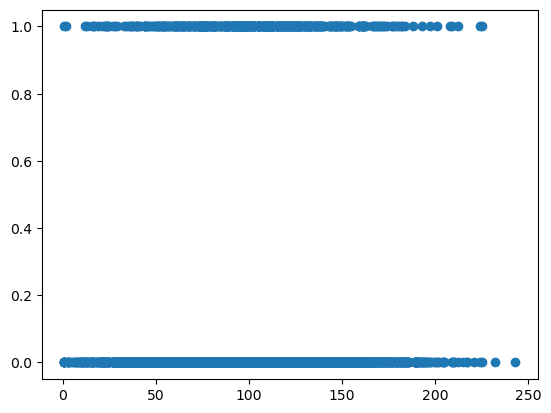

In [5]:
import matplotlib.pyplot as plt

y = df['Churn'].values
x = df['AccountWeeks'].values;
plt.scatter(x, y)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

selected = ['AccountWeeks', 'ContractRenewal', 'DataUsage', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins', 'ContractRenewal', 'DataPlan', 'CustServCalls']
x = df[selected].values
y = df['Churn'].values


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2)

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso_model.fit(x_train,y_train)




,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [9]:

from sklearn.metrics import  classification_report, confusion_matrix, roc_auc_score

y_pred = lasso_model.predict(x_test)
y_prob = lasso_model.predict_proba(x_test)[:, 1]

#Print Confusion Matrix (Raw counts)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

#Print Precision, Recall, F1-Score, and Accuracy
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Print ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.3f}")

--- Confusion Matrix ---
[[563  10]
 [ 77  17]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       573
           1       0.63      0.18      0.28        94

    accuracy                           0.87       667
   macro avg       0.75      0.58      0.60       667
weighted avg       0.84      0.87      0.84       667

ROC-AUC Score: 0.812


In [10]:
#Retraining 

lasso_model = LogisticRegression(class_weight='balanced' ,penalty='l1', solver='liblinear', C=0.5)
lasso_model.fit(x_train,y_train)

y_pred = lasso_model.predict(x_test)
y_prob = (lasso_model.predict_proba(x_test)[:, 1] >= 0.3).astype(int)

#Print Confusion Matrix (Raw counts)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

#Print Precision, Recall, F1-Score, and Accuracy
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Print ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.3f}")

--- Confusion Matrix ---
[[449 124]
 [ 24  70]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       573
           1       0.36      0.74      0.49        94

    accuracy                           0.78       667
   macro avg       0.66      0.76      0.67       667
weighted avg       0.87      0.78      0.81       667

ROC-AUC Score: 0.698


In [11]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Test thresholds from 0.30 to 0.50
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_temp = (lasso_model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
    p = precision_score(y_test, y_pred_temp)
    r = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    print(f"Threshold: {threshold:.2f} | Precision: {p:.2f} | Recall: {r:.2f} | F1-Score: {f1:.2f}")

Threshold: 0.30 | Precision: 0.23 | Recall: 0.88 | F1-Score: 0.36
Threshold: 0.35 | Precision: 0.26 | Recall: 0.85 | F1-Score: 0.40
Threshold: 0.40 | Precision: 0.29 | Recall: 0.81 | F1-Score: 0.43
Threshold: 0.45 | Precision: 0.33 | Recall: 0.79 | F1-Score: 0.47
Threshold: 0.50 | Precision: 0.36 | Recall: 0.74 | F1-Score: 0.49


In [13]:
for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_temp = (lasso_model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
    p = precision_score(y_test, y_pred_temp)
    r = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    print(f"Threshold: {threshold:.2f} | Precision: {p:.2f} | Recall: {r:.2f} | F1-Score: {f1:.2f}")

Threshold: 0.50 | Precision: 0.36 | Recall: 0.74 | F1-Score: 0.49
Threshold: 0.55 | Precision: 0.40 | Recall: 0.71 | F1-Score: 0.52
Threshold: 0.60 | Precision: 0.41 | Recall: 0.66 | F1-Score: 0.51
Threshold: 0.65 | Precision: 0.42 | Recall: 0.53 | F1-Score: 0.47
Threshold: 0.70 | Precision: 0.44 | Recall: 0.44 | F1-Score: 0.44


In [14]:
#Retraining 

lasso_model = LogisticRegression(class_weight='balanced' ,penalty='l1', solver='liblinear', C=0.5)
lasso_model.fit(x_train,y_train)

y_pred = lasso_model.predict(x_test)
y_prob = (lasso_model.predict_proba(x_test)[:, 1] >= 0.55).astype(int)

#Print Confusion Matrix (Raw counts)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

#Print Precision, Recall, F1-Score, and Accuracy
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Print ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.3f}")

--- Confusion Matrix ---
[[449 124]
 [ 24  70]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       573
           1       0.36      0.74      0.49        94

    accuracy                           0.78       667
   macro avg       0.66      0.76      0.67       667
weighted avg       0.87      0.78      0.81       667

ROC-AUC Score: 0.770
